#### 0. Install dependencies

In [1]:
import numpy as np
import h5py
import importlib

from gtda.plotting import plot_point_cloud


import pickle
from pathlib import Path

# Визуализация

In [2]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
# sorting is optional i just think it looks better this way
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[0]) # change number in brackets to plot different digits

Точки в облаках расположены достаточно плотно. Внутри цифры полые.

# Нормализация
Согласно документации датасета, все облака точек должны быть нормализованы. Проверим это, собрав статистику по каждой цифре отдельно и по всем цифрам сразу.

In [ ]:
import utils.stat
importlib.reload(utils.stat)

class_stats, global_stats = utils.stat.compute_statistics(train_file)

In [12]:
class_stats

num_points                                      range_x        range_y  \
      num_clouds        mean        std    min    max    mean    std    mean   
label                                                                          
0            479  27806.3674  2404.0861  19050  35400  0.3000  0.000  0.9065   
1            563  13510.6572  2211.8518   9250  26850  0.3000  0.000  0.4898   
2            488  24701.2295  3273.3208  14600  32400  0.3000  0.000  0.9172   
3            493  25364.5030  3462.8836  14550  33550  0.3000  0.000  0.8404   
4            535  21927.7570  2667.0957  14950  28300  0.3000  0.000  0.8257   
5            434  24189.2857  3614.6889  15900  35600  0.3000  0.000  0.9144   
6            501  22882.1357  3531.0587  14450  37300  0.3000  0.000  0.7500   
7            550  20357.0909  2637.8022  13150  27600  0.3001  0.001  0.8112   
8            462  25543.9394  3563.1286  15250  38200  0.3000  0.000  0.7985   
9            495  21867.9798  2837.9709  12100  30600  0.3000  0.000  0.7201   

              range_z          
          std    mean     std  
label                          
0      0.1138  0.9827  0.0532  
1      0.2016  0.9996  0.0087  
2      0.1172  0.9553  0.0883  
3      0.1393  0.9941  0.0288  
4      0.1400  0.9942  0.0266  
5      0.1223  0.9461  0.0928  
6      0.1477  0.9954  0.0284  
7      0.1433  0.9916  0.0366  
8      0.1462  0.9936  0.0342  
9      0.1336  0.9986  0.0126

Наиболее заметное различие наблюдается в количестве точек: цифры 0 и 8 представлены наиболее плотными облаками, в то время как цифра 1 содержит существенно меньше точек.
По пространственным характеристикам все объекты имеют практически идентичный диапазон по оси X, что обусловлено особенностями генерации датасета. В то же время по осям Y и Z наблюдаются выраженные класс-специфичные различия. Цифра 1 характеризуется вытянутостью (относительно узкий диапазон по Y), в то время как цифры 0, 2 и 5 имеют более сбалансированные пропорции. Классы демонстрируют диапазон по Z близкий к 1.0.

In [13]:
global_stats

,mean,std,min,max
num_points,22600.0900,4895.4854,9250.00,38200.0000
range_x,0.3000,0.0003,0.30,0.3158
range_y,0.7915,0.1899,0.15,1.0000
range_z,0.9859,0.0509,0.50,1.0000
label,4.4670,2.8722,0.00,9.0000


# Сэмплирование

In [3]:
import utils.subsampling
importlib.reload(utils.subsampling)

<module 'utils.subsampling' from 'c:\\Users\\zhilk\\vscode projects\\topology-mnist3d\\utils\\subsampling.py'>

In [5]:
point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=50)

Облака содержат очень много точек. Симплициальные комплексы долго считаются и могут не влезать в память. Попробуем сэмплировать точки.

In [9]:
import utils.subsampling
importlib.reload(utils.subsampling)

to_subsample, labels_subsampled = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=1)
subsampled_point_clouds = utils.subsampling.subsample_point_clouds(to_subsample, 5000)

plot_point_cloud(subsampled_point_clouds[0])

# Симплициальные комплексы и диаграммы персистентности

## Альфа комплекс

In [ ]:
import utils.persistence
importlib.reload(utils.persistence)

trees, diagrams = utils.persistence.build_diagrams(point_clouds)

Processing clouds: 100%|██████████| 10/10 [00:00<00:00, 681.59it/s]


In [206]:
import utils.persistence
importlib.reload(utils.persistence)

trees_sub, diagrams_sub = utils.persistence.build_diagrams(subsampled_point_clouds)

Processing clouds: 100%|██████████| 4000/4000 [03:40<00:00, 18.10it/s]


### Сохранение и загрузка диаграмм

In [207]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

subsampled_trees_path = Path("./data/tda/subsampled_simplex_trees_gudhi.pkl")
subsampled_diagrams_path = Path("./data/tda/subsampled_persistence_diagrams_gudhi.pkl")

In [208]:
import utils.save_load
importlib.reload(utils.save_load)

#utils.save_load.save_tree_diagram(diagrams_path, diagrams, trees_path, trees)
utils.save_load.save_tree_diagram(subsampled_diagrams_path, diagrams_sub, subsampled_trees_path, trees_sub)

Trees saved to data\tda\subsampled_simplex_trees_gudhi.pkl
Diagrams saved to data\tda\subsampled_persistence_diagrams_gudhi.pkl


In [209]:
import utils.save_load
importlib.reload(utils.save_load)

# diagrams_loaded = diagrams if diagrams is not None else utils.save_load.load_object(diagrams_path)
subsampled_diagrams_loaded = diagrams_sub if diagrams_sub is not None else utils.save_load.load_object(subsampled_diagrams_path)

### Отрисовка диаграмм

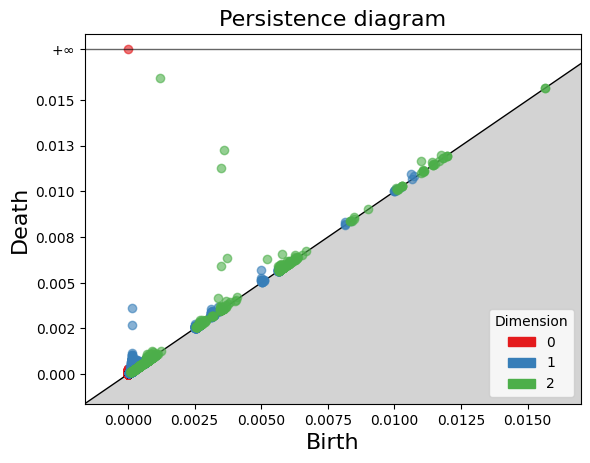

In [114]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_persistence(subsampled_diagrams_loaded, labels, 8)

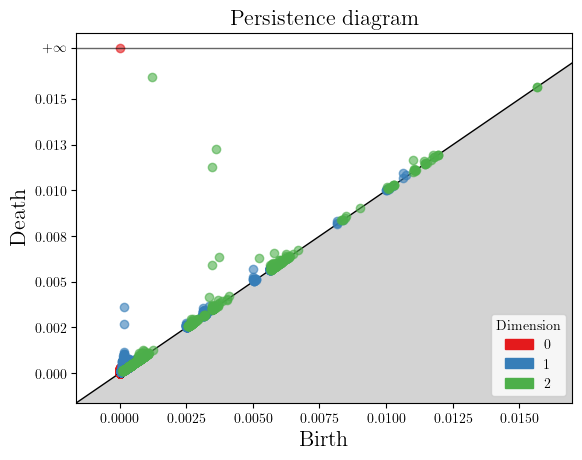

In [15]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_persistance(subsampled_diagrams_loaded, labels_subsampled, 8)

#### 7. Vectorization

In [ ]:
import utils.save_load
importlib.reload(utils.save_load)

subsampled_trees_loaded = trees_sub if trees_sub is not None else utils.save_load.load_object(subsampled_trees_path)

In [211]:
from tqdm import tqdm

for tree in tqdm(subsampled_trees_loaded, desc="Processing trees"):
  tree.persistence()

Processing trees:   0%|          | 0/4000 [00:00<?, ?it/s]

Processing trees: 100%|██████████| 4000/4000 [06:04<00:00, 10.96it/s]


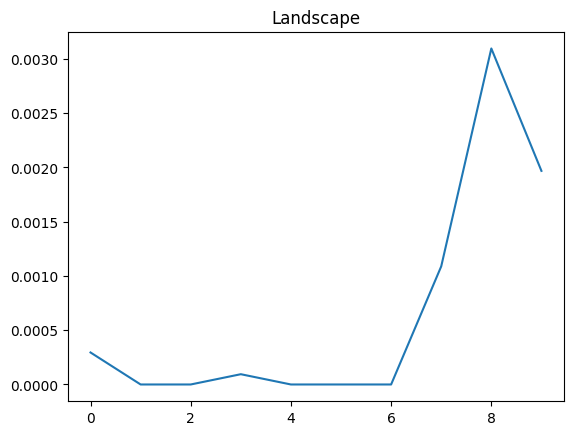

In [ ]:
from gudhi.representations import Landscape
from matplotlib import pyplot as plt

LS = Landscape(
    num_landscapes=1,
    resolution=10,
    )

idx = np.where(labels_subsampled == 3)[0][2]
L = LS.fit_transform([subsampled_trees_loaded[idx].persistence_intervals_in_dimension(1)])

plt.plot(L[0][:5000])
plt.title("Landscape")
plt.show()

In [212]:
# переводим в gtda формат
diagrams_sub_gtda = [
    np.array([
        [birth, death, dim]
        for dim, (birth, death) in diag
    ])
    for diag in tqdm(diagrams_sub)
]

100%|██████████| 4000/4000 [02:10<00:00, 30.55it/s]


In [242]:
def top_k(diag, k=50):
    """
    Принимает диаграмму персистентности и оставляет k лучших (наиболее далеких от диагонали) точек.
    """
    pers = diag[:, 1] - diag[:, 0]  # death - birth
    idx = np.argsort(pers)[::-1][:k]    # индексы самых устойчивых объектов
    return diag[idx]

X_h1_top = [top_k(d[d[:, 2] == 1], k=50)    # только h1
            for d in diagrams_sub_gtda]

X = np.stack(X_h1_top)

In [235]:
from gtda.diagrams import PersistenceLandscape

PL = PersistenceLandscape(n_layers=5, n_bins=300, n_jobs=-1)
landscapes = PL.fit_transform(X)

In [ ]:
idx = np.where(labels_subsampled == 1)[0][2]
PL.plot(landscapes, sample=idx)

4000
(4000, 1500)
Accuracy =  0.53
F1 score =  0.5273148974972944
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        50
           1       0.84      0.92      0.88        50
           2       0.37      0.32      0.34        50
           3       0.47      0.44      0.45        50
           4       0.28      0.30      0.29        50
           5       0.31      0.26      0.28        50
           6       0.46      0.38      0.42        50
           7       0.37      0.46      0.41        50
           8       0.85      0.68      0.76        50
           9       0.53      0.68      0.60        50

    accuracy                           0.53       500
   macro avg       0.53      0.53      0.53       500
weighted avg       0.53      0.53      0.53       500

[[43  0  0  0  0  1  0  0  1  5]
 [ 0 46  0  0  0  0  0  4  0  0]
 [ 0  0 16  5  9  3  4  9  2  2]
 [ 1  1  5 22  5  6  2  7  0  1]
 [ 0  0  5  5 15  9  3 12  0  1]
 [ 1  0  7

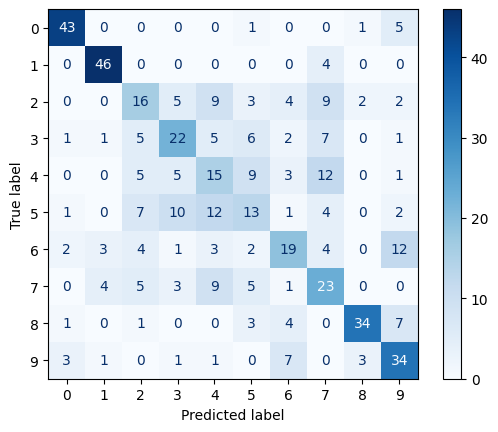

In [245]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Y = labels_subsampled
print(Y.shape[0])
s = Y.shape[0]

X_squeezed = np.reshape(landscapes, (Y.shape[0],-1))
print(X_squeezed.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_squeezed,
    Y,
    test_size=1/8,
    random_state=42,
    stratify=Y
)

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

clf = HistGradientBoostingClassifier(
	#max_iter=5000,
    #oob_score=True,
    random_state=42,
	#n_jobs=-1
)

clf.fit(X_train, y_train)

#print(f"OOB score: {clf.oob_score_:.3f}")

y_test_pred = clf.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_test_pred))
print("F1 score = ", f1_score(y_test, y_test_pred, average="macro"))
print(classification_report(y_test,y_test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

## Комплекс Вьеториса-Рипса

In [10]:
from gtda.homology import VietorisRipsPersistence

homology_dimensions = [0, 1, 2]

persistence = VietorisRipsPersistence(
    homology_dimensions=homology_dimensions,
    n_jobs=-1
)

In [ ]:
diagrams = persistence.fit_transform(subsampled_point_clouds)